In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [162]:
df = pd.read_csv('../Data/data.csv')
df.head()

,Timestamp,Date,Symbol,Open,High,Low,Close,Volume BTC,Volume USD
0,1676939580000,2023-02-21 00:33:00,BTC/USD,24859.34,24859.34,24859.34,24859.34,0.000000,0.000000
1,1676939520000,2023-02-21 00:32:00,BTC/USD,24821.96,24859.34,24821.96,24859.34,0.103099,2562.977818
2,1676939460000,2023-02-21 00:31:00,BTC/USD,24818.09,24821.96,24815.47,24821.96,0.090640,2249.866178
3,1676939400000,2023-02-21 00:30:00,BTC/USD,24812.25,24818.09,24812.25,24818.09,0.002203,54.681450
4,1676939340000,2023-02-21 00:29:00,BTC/USD,24809.27,24812.25,24809.27,24812.25,0.090675,2249.862431


In [163]:
df.describe()

,Timestamp,Open,High,Low,Close,Volume BTC,Volume USD
count,3.766763e+06,3.766763e+06,3.766763e+06,3.766763e+06,3.766763e+06,3.766763e+06,3.766763e+06
mean,9.633091e+11,1.497170e+04,1.497938e+04,1.496394e+04,1.497171e+04,2.082630e+00,2.390526e+04
std,7.879469e+11,1.658607e+04,1.659550e+04,1.657636e+04,1.658607e+04,1.681797e+01,1.135481e+05
min,1.444312e+09,0.000000e+00,2.425000e+02,0.000000e+00,2.360000e+02,0.000000e+00,0.000000e+00
25%,1.500813e+09,2.750000e+03,2.750650e+03,2.749840e+03,2.750000e+03,0.000000e+00,0.000000e+00
50%,1.560047e+12,8.493230e+03,8.497840e+03,8.489520e+03,8.493240e+03,7.482203e-02,8.237107e+02
75%,1.620006e+12,2.038378e+04,2.039286e+04,2.037482e+04,2.038379e+04,9.309989e-01,1.142039e+04
max,1.676940e+12,6.899887e+04,6.900000e+04,6.878700e+04,6.899887e+04,8.264463e+03,3.749580e+07


In [164]:
df.isna().sum()

Timestamp     0
Date          0
Symbol        0
Open          0
High          0
Low           0
Close         0
Volume BTC    0
Volume USD    0
dtype: int64

In [165]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [166]:
df_4h = df.resample('4H').agg({
    'Open' : 'first',
    'High' : 'max',
    'Low' : 'min',
    'Close' : 'last',
    'Volume BTC' : 'sum',
    'Volume USD' : 'sum'
})
df_4h.dropna(inplace=True)
df_4h.head()

C:\Users\User\AppData\Local\Temp\ipykernel_189208\613425973.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_4h = df.resample('4H').agg({


,Open,High,Low,Close,Volume BTC,Volume USD
Date,,,,,,
2015-10-08 12:00:00,0.00,245.00,0.0,244.92,8.077229,1977.745452
2015-10-08 16:00:00,244.92,244.99,244.0,244.00,13.037812,3187.597961
2015-10-08 20:00:00,244.00,244.00,243.6,243.95,10.639661,2595.066878
2015-10-09 00:00:00,243.95,243.95,243.6,243.60,3.000000,730.800000
2015-10-09 04:00:00,243.60,243.60,243.6,243.60,0.000000,0.000000


In [167]:
df_4h['Target'] = df_4h['Close'].shift(-1)
df_4h.head()

,Open,High,Low,Close,Volume BTC,Volume USD,Target
Date,,,,,,,
2015-10-08 12:00:00,0.00,245.00,0.0,244.92,8.077229,1977.745452,244.00
2015-10-08 16:00:00,244.92,244.99,244.0,244.00,13.037812,3187.597961,243.95
2015-10-08 20:00:00,244.00,244.00,243.6,243.95,10.639661,2595.066878,243.60
2015-10-09 00:00:00,243.95,243.95,243.6,243.60,3.000000,730.800000,243.60
2015-10-09 04:00:00,243.60,243.60,243.6,243.60,0.000000,0.000000,243.63


In [168]:
df_4h.dropna(inplace=True)
df_4h.isna().sum()

Open          0
High          0
Low           0
Close         0
Volume BTC    0
Volume USD    0
Target        0
dtype: int64

In [169]:
df_4h["Close1%"] = (df_4h["Close"].shift(1) - df_4h["Close"]) / df_4h["Close"] * 100
df_4h["Close2%"] = -1 * (df_4h["Close"].shift(2) - df_4h["Close"]) / df_4h["Close"] * 100
df_4h["Close3%"] = -1 * (df_4h["Close"].shift(3) - df_4h["Close"]) / df_4h["Close"] * 100
df_4h["Close_day%"] = -1 * (df_4h["Close"].shift(7) - df_4h["Close"]) / df_4h["Close"] * 100

df_4h["Body%"] = -1 * (df_4h["Close"] - df_4h["Open"]) / df_4h["Close"] * 100
df_4h["Movement"] = df_4h["High"] - df_4h["Low"]
df_4h["Movement%"]  = ((df_4h["High"] - df_4h["Low"]) / df_4h["Close"]) * 100
df_4h["mvm_avg7%"]  = df_4h.rolling(window=7)["Movement%"].mean()
df_4h["mvm_avg14%"] = df_4h.rolling(window=14)["Movement%"].mean()

df_4h["SMA7%"]  = (df_4h.rolling(window=7)['Close'].mean() - df_4h['Close']) / df_4h['Close'] * 100
df_4h["SMA14%"] = (df_4h.rolling(window=14)['Close'].mean() - df_4h['Close']) / df_4h['Close'] * 100
df_4h["SMA21%"] = (df_4h.rolling(window=21)['Close'].mean() - df_4h['Close']) / df_4h['Close'] * 100
df_4h.dropna(inplace=True)
df_4h.head()

,Open,High,Low,Close,Volume BTC,Volume USD,Target,Close1%,Close2%,Close3%,Close_day%,Body%,Movement,Movement%,mvm_avg7%,mvm_avg14%,SMA7%,SMA14%,SMA21%
Date,,,,,,,,,,,,,,,,,,,
2015-10-11 20:00:00,248.24,249.50,247.77,249.50,3.841956,954.048804,248.98,-0.505010,1.282565,1.282565,1.655311,-0.505010,1.73,0.693387,0.284206,0.403625,-0.988262,-1.374463,-1.656837
2015-10-12 00:00:00,249.50,249.50,248.98,248.98,8.340306,2076.577525,248.71,0.208852,0.297213,1.076392,1.076392,0.208852,0.52,0.208852,0.260101,0.408007,-0.627704,-1.027334,-1.373796
2015-10-12 04:00:00,248.98,248.98,248.71,248.71,0.230000,57.203300,247.72,0.108560,-0.317639,0.188975,0.969000,0.108560,0.27,0.108560,0.275609,0.243732,-0.381397,-0.824540,-1.176547
2015-10-12 08:00:00,248.71,248.71,247.72,247.72,11.060274,2741.613524,247.62,0.399645,-0.508639,-0.718553,0.573228,0.399645,0.99,0.399645,0.332701,0.267914,0.098614,-0.364467,-0.709134
2015-10-12 12:00:00,247.72,247.90,247.62,247.62,30.968000,7669.163180,247.60,0.040384,-0.440191,-0.549229,0.533075,0.040384,0.28,0.113076,0.348855,0.249508,0.215191,-0.261634,-0.591728


In [170]:
df_4h["Target"] = (df_4h["Target"] - df_4h["Close"]) / df_4h["Close"] * 100

df_4h.head(20)

,Open,High,Low,Close,Volume BTC,Volume USD,Target,Close1%,Close2%,Close3%,Close_day%,Body%,Movement,Movement%,mvm_avg7%,mvm_avg14%,SMA7%,SMA14%,SMA21%
Date,,,,,,,,,,,,,,,,,,,
2015-10-11 20:00:00,248.24,249.50,247.77,249.50,3.841956,954.048804,-0.208417,-0.505010,1.282565,1.282565,1.655311,-0.505010,1.73,0.693387,0.284206,0.403625,-0.988262,-1.374463,-1.656837
2015-10-12 00:00:00,249.50,249.50,248.98,248.98,8.340306,2076.577525,-0.108442,0.208852,0.297213,1.076392,1.076392,0.208852,0.52,0.208852,0.260101,0.408007,-0.627704,-1.027334,-1.373796
2015-10-12 04:00:00,248.98,248.98,248.71,248.71,0.230000,57.203300,-0.398054,0.108560,-0.317639,0.188975,0.969000,0.108560,0.27,0.108560,0.275609,0.243732,-0.381397,-0.824540,-1.176547
2015-10-12 08:00:00,248.71,248.71,247.72,247.72,11.060274,2741.613524,-0.040368,0.399645,-0.508639,-0.718553,0.573228,0.399645,0.99,0.399645,0.332701,0.267914,0.098614,-0.364467,-0.709134
2015-10-12 12:00:00,247.72,247.90,247.62,247.62,30.968000,7669.163180,-0.008077,0.040384,-0.440191,-0.549229,0.533075,0.040384,0.28,0.113076,0.348855,0.249508,0.215191,-0.261634,-0.591728
2015-10-12 16:00:00,247.62,247.91,247.60,247.60,6.608900,1636.976238,0.000000,0.008078,-0.048465,-0.448304,0.525040,0.008078,0.31,0.125202,0.366741,0.233630,0.298292,-0.167032,-0.506770
2015-10-12 20:00:00,247.60,247.61,247.60,247.60,5.580000,1381.609000,-0.747173,0.000000,-0.008078,-0.048465,-0.258481,-0.000000,0.01,0.004039,0.236109,0.210630,0.261366,-0.102700,-0.430418
2015-10-13 00:00:00,247.60,247.60,245.75,245.75,16.600569,4096.506460,0.915565,0.752798,-0.752798,-0.760936,-1.525941,0.752798,1.85,0.752798,0.244596,0.264401,0.798140,0.660369,0.353049
2015-10-13 04:00:00,245.75,248.00,245.75,248.00,18.342363,4536.009201,1.963710,-0.907258,0.161290,0.161290,-0.395161,-0.907258,2.25,0.907258,0.344368,0.302234,-0.172811,-0.203917,-0.481759


In [171]:
X = df_4h.drop('Target', axis=1)
y = df_4h['Target']

X_train = X.iloc[:int(0.8*len(X))]
y_train = y.iloc[:int(0.8*len(y))]
X_test = X.iloc[int(0.8*len(X)):]
y_test = y.iloc[int(0.8*len(y)):]

In [172]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

In [173]:
rf_model = RandomForestRegressor(
    n_estimators=101,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

In [174]:
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [175]:
print("mean sq err :", mean_squared_error(y_test, y_pred))
print("mean absolute err : ", mean_absolute_error(y_test, y_pred))

mean sq err : 1.8214269680986317
mean absolute err :  0.9048813513642436


In [176]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.02,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [177]:
print("mean sq err :", mean_squared_error(y_test, y_pred))
print("mean absolute err : ", mean_absolute_error(y_test, y_pred))

mean sq err : 1.8121253624230875
mean absolute err :  0.8965167210888139


In [178]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):
    param = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        # 'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1,
        'device': 'gpu',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5)
    }

    model = xgb.XGBRegressor(**param)

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("Best Parameters:", study.best_params)
print("Best RMSE:", study.best_value)


[I 2026-05-24 10:34:22,280] A new study created in memory with name: no-name-da549c0f-c40f-4e92-abbf-6427c9e7a1b6
[I 2026-05-24 10:34:26,781] Trial 0 finished with value: 1.3164476566557428 and parameters: {'n_estimators': 327, 'max_depth': 3, 'learning_rate': 0.012955244965368228, 'subsample': 0.760557732789972, 'colsample_bytree': 0.789260898378637, 'gamma': 0.40978084797399217}. Best is trial 0 with value: 1.3164476566557428.
[I 2026-05-24 10:34:27,958] Trial 1 finished with value: 1.358755782648819 and parameters: {'n_estimators': 217, 'max_depth': 6, 'learning_rate': 0.06943398006731381, 'subsample': 0.9425454899562064, 'colsample_bytree': 0.7745086737923602, 'gamma': 0.06827461663540063}. Best is trial 0 with value: 1.3164476566557428.
[I 2026-05-24 10:34:30,153] Trial 2 finished with value: 1.3432842823764193 and parameters: {'n_estimators': 273, 'max_depth': 9, 'learning_rate': 0.022912344693019483, 'subsample': 0.9974590915048765, 'colsample_bytree': 0.6687870512764246, 'gamma

Best Parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01586175936936573, 'subsample': 0.6070602365235291, 'colsample_bytree': 0.9369180115772464, 'gamma': 0.49250156064635087}
Best RMSE: 1.3150162744974447


In [179]:
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    # 'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
    'device': 'gpu'
}

model = XGBRegressor(**params, **study.best_params)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [180]:
print("mean sq err :", mean_squared_error(y_test, y_pred))
print("mean absolute err : ", mean_absolute_error(y_test, y_pred))

mean sq err : 1.7292678021931387
mean absolute err :  0.8607051751858779


In [181]:
import pandas_ta as ta

In [182]:
df_4h.ta.rsi(length=14, append = True)

df_4h.ta.macd(fast=12, slow=26, signal=9, append=True)

df_4h.ta.atr(length=14, append=True)

df_4h.ta.bbands(length=20, std=2, append=True)

df_4h.dropna(inplace=True)

print(df_4h.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USD', 'Target',
       'Close1%', 'Close2%', 'Close3%', 'Close_day%', 'Body%', 'Movement',
       'Movement%', 'mvm_avg7%', 'mvm_avg14%', 'SMA7%', 'SMA14%', 'SMA21%',
       'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'ATRr_14',
       'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0',
       'BBP_20_2.0_2.0'],
      dtype='object')


In [183]:
df_4h["ATRr_14%"] = (df_4h["ATRr_14"] / df_4h["Close"]) * 100

cols_to_drop = ['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USD', "ATRr_14", "Movement"]

X = df_4h.drop(columns=['Target'] + cols_to_drop)
y = df_4h['Target']

In [184]:
X_train = X.iloc[:int(0.8*len(X))]
y_train = y.iloc[:int(0.8*len(y))]
X_test = X.iloc[int(0.8*len(X)):]
y_test = y.iloc[int(0.8*len(y)):]

In [185]:
X.head()

,Close1%,Close2%,Close3%,Close_day%,Body%,Movement%,mvm_avg7%,mvm_avg14%,SMA7%,SMA14%,...,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,ATRr_14%
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-17 08:00:00,-1.575550,1.528137,3.716401,6.557497,-1.575550,2.326854,3.712054,2.460964,-2.654572,-4.585715,...,78.475978,5.698446,1.601825,4.096621,245.320345,258.9645,272.608655,10.537471,1.057950,1.915999
2015-10-17 12:00:00,0.252285,1.327239,1.279707,5.228519,0.252285,1.173675,3.641627,2.508233,-1.662053,-3.885349,...,76.438219,6.022896,1.541020,4.481876,245.530660,260.0895,274.648340,11.195254,0.960562,1.867464
2015-10-17 16:00:00,2.052239,-2.309701,-0.697761,0.962687,2.052239,2.332090,3.394032,2.593728,0.493603,-1.578891,...,62.505583,5.769711,1.030268,4.739443,246.602977,260.9320,275.261023,10.982956,0.746632,1.936239
2015-10-17 20:00:00,-1.640548,-0.378023,-0.631262,2.484677,-1.640548,1.746981,2.861838,2.623389,-0.800088,-2.743683,...,67.664226,5.862176,0.898186,4.963989,247.204773,261.9055,276.606227,11.225978,0.859319,1.893225
2015-10-18 00:00:00,1.192156,0.467949,-1.574686,1.953502,1.192156,2.090916,2.776341,2.662918,0.661602,-1.308348,...,61.156982,5.611746,0.518205,5.093541,248.126140,262.6725,277.218860,11.075663,0.726431,1.928304


In [186]:
rf_model = RandomForestRegressor(
    n_estimators=101,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

In [187]:
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [188]:
print("mean sq err :", mean_squared_error(y_test, y_pred))
print("mean absolute err : ", mean_absolute_error(y_test, y_pred))

mean sq err : 1.812965340293499
mean absolute err :  0.910492618781547


In [189]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):
    param = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        # 'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1,
        'device': 'gpu',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5)
    }

    model = xgb.XGBRegressor(**param)

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("Best Parameters:", study.best_params)
print("Best RMSE:", study.best_value)


[I 2026-05-24 10:35:14,450] A new study created in memory with name: no-name-999dde8d-5bd8-42c0-bc70-6ea9f4f8e43b
[I 2026-05-24 10:35:16,052] Trial 0 finished with value: 1.3442453179159985 and parameters: {'n_estimators': 231, 'max_depth': 9, 'learning_rate': 0.021738124555503176, 'subsample': 0.6815470758331206, 'colsample_bytree': 0.727065062241498, 'gamma': 0.20881261065675988}. Best is trial 0 with value: 1.3442453179159985.
[I 2026-05-24 10:35:17,366] Trial 1 finished with value: 1.510336164861838 and parameters: {'n_estimators': 431, 'max_depth': 7, 'learning_rate': 0.15891341582113291, 'subsample': 0.9167675729302576, 'colsample_bytree': 0.8558224228554944, 'gamma': 0.2714897854612459}. Best is trial 0 with value: 1.3442453179159985.
[I 2026-05-24 10:35:19,634] Trial 2 finished with value: 1.3858307638160179 and parameters: {'n_estimators': 286, 'max_depth': 9, 'learning_rate': 0.03717329264471397, 'subsample': 0.7786161118437624, 'colsample_bytree': 0.614207531044197, 'gamma':

Best Parameters: {'n_estimators': 135, 'max_depth': 3, 'learning_rate': 0.01933439102278073, 'subsample': 0.8619771232083809, 'colsample_bytree': 0.9486230650162857, 'gamma': 0.4127866383788541}
Best RMSE: 1.3164926016471064


In [190]:
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    # 'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
    'device': 'gpu'
}

model = XGBRegressor(**params, **study.best_params)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [191]:
print("mean sq err :", mean_squared_error(y_test, y_pred))
print("mean absolute err : ", mean_absolute_error(y_test, y_pred))

mean sq err : 1.7331527701915668
mean absolute err :  0.8624873015020015


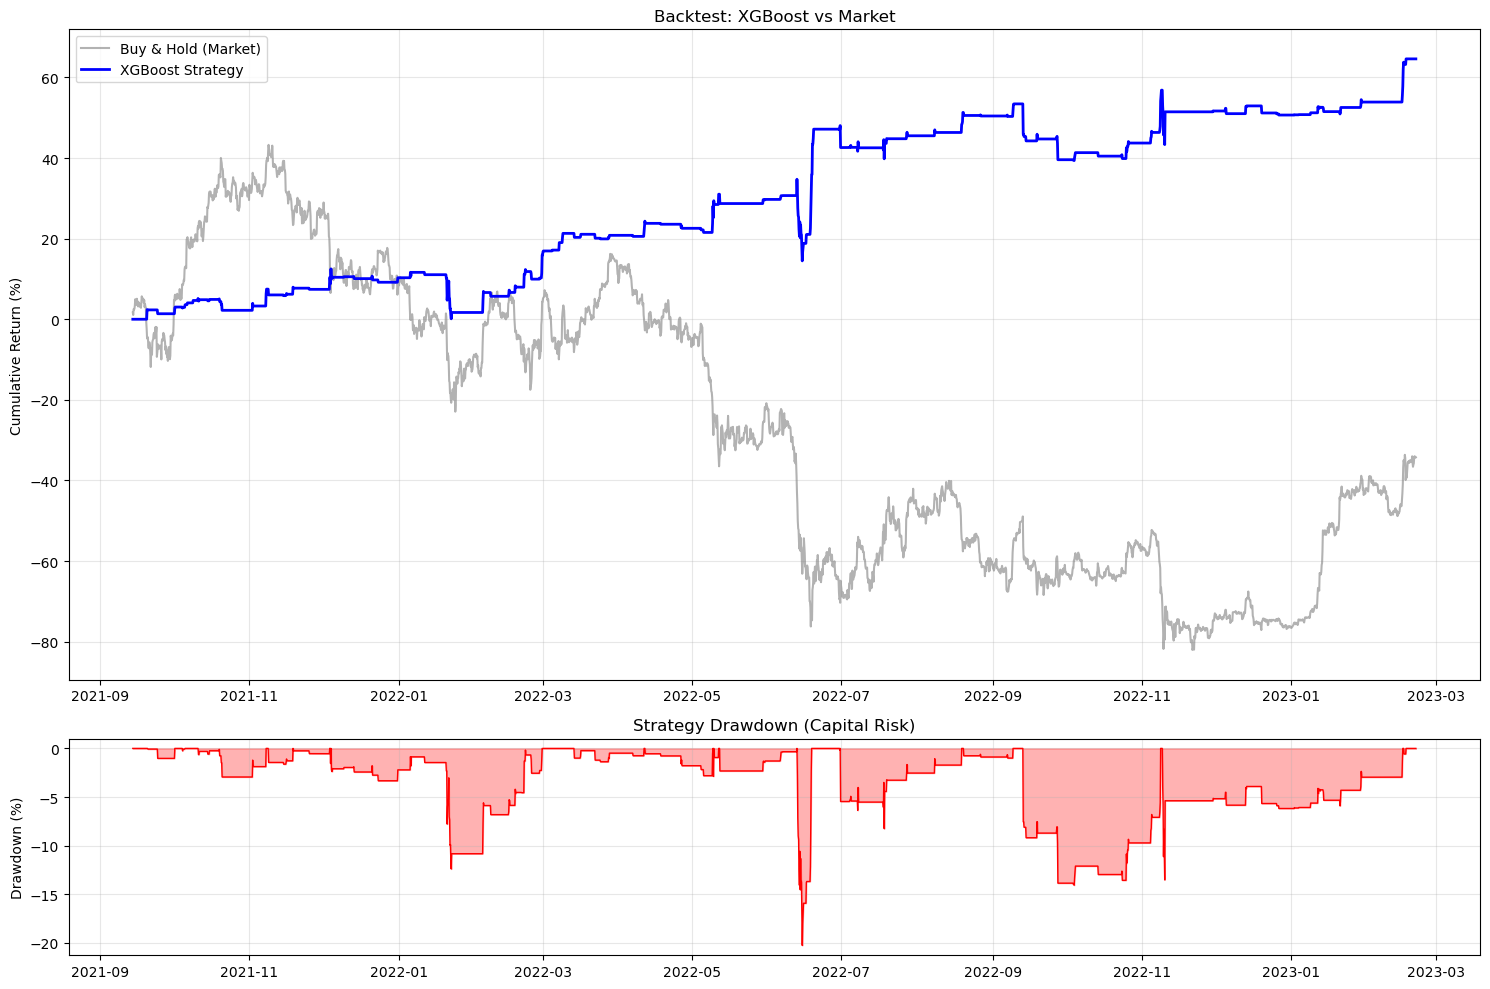

========== QUANT TRADING REPORT ==========
Total Market Return   : -34.26%
Total Strategy Return : 64.60%
------------------------------------------
Total Trades Executed : 261
Winning Trades        : 147
Losing Trades         : 114
Win Rate              : 56.32%
Maximum Drawdown      : -20.25%


In [195]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bt_df = pd.DataFrame({
    'Actual_Return': y_test,
    'Predicted_Return': y_pred
})

threshold = 0.1

bt_df['Signal'] = 0
bt_df.loc[bt_df['Predicted_Return'] > threshold, 'Signal'] = 1
bt_df.loc[bt_df['Predicted_Return'] < -threshold, 'Signal'] = -1

bt_df['Strategy_Return'] = bt_df['Signal'] * bt_df['Actual_Return']
bt_df['Market_Cum_Return'] = bt_df['Actual_Return'].cumsum()
bt_df['Strategy_Cum_Return'] = bt_df['Strategy_Return'].cumsum()

active_trades = bt_df[bt_df['Signal'] != 0]
total_trades = len(active_trades)

winning_trades = len(active_trades[active_trades['Strategy_Return'] > 0])
losing_trades = len(active_trades[active_trades['Strategy_Return'] < 0])

win_rate = (winning_trades / total_trades) * 100 if total_trades > 0 else 0

bt_df['Peak'] = bt_df['Strategy_Cum_Return'].cummax()

bt_df['Drawdown'] = bt_df['Strategy_Cum_Return'] - bt_df['Peak']
max_drawdown = bt_df['Drawdown'].min()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(bt_df.index, bt_df['Market_Cum_Return'], label='Buy & Hold (Market)', color='gray', alpha=0.6)
ax1.plot(bt_df.index, bt_df['Strategy_Cum_Return'], label='XGBoost Strategy', color='blue', linewidth=2)
ax1.set_title('Backtest: XGBoost vs Market')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.fill_between(bt_df.index, bt_df['Drawdown'], 0, color='red', alpha=0.3)
ax2.plot(bt_df.index, bt_df['Drawdown'], color='red', linewidth=1)
ax2.set_title('Strategy Drawdown (Capital Risk)')
ax2.set_ylabel('Drawdown (%)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("========== QUANT TRADING REPORT ==========")
print(f"Total Market Return   : {bt_df['Market_Cum_Return'].iloc[-1]:.2f}%")
print(f"Total Strategy Return : {bt_df['Strategy_Cum_Return'].iloc[-1]:.2f}%")
print("-" * 42)
print(f"Total Trades Executed : {total_trades}")
print(f"Winning Trades        : {winning_trades}")
print(f"Losing Trades         : {losing_trades}")
print(f"Win Rate              : {win_rate:.2f}%")
print(f"Maximum Drawdown      : {max_drawdown:.2f}%")
print("==========================================")